In [104]:
from vae_project.imports import *
from vae_project.dataset import *
from vae_project.utils import *
from vae_project.models import VAE, IWAE, VampPriorVAE

import torch
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
import torchvision as tv

from vae_project.models.latent_analysis import (
    get_latent_codes,
    compute_active_units,
    kl_per_dimension,
    linear_probe,
    plot_latent_2d,
    latent_traversal,
)




In [73]:
def load_all_models(device):
    MODELS = {}

    # --- 1) VAE ---
    vae = VAE((3,32,64,128), input_size=(32,32), latent_dim=16, h_dim=64, recon_dist='bce')
    vae.load_state_dict(torch.load("./checkpoints/vae_final.pt", map_location=device))
    vae.to(device).eval()
    MODELS["VAE"] = vae

    # --- 2) IWAE ---
    iwae = IWAE((3,32,64,128), input_size=(32,32), latent_dim=16, h_dim=64)
    iwae.load_state_dict(torch.load("./checkpoints/iwae_final.pt", map_location=device))
    iwae.to(device).eval()
    MODELS["IWAE"] = iwae

    # --- 3) VampPriorVAE ---
    vamp = VampPriorVAE(
        encoder_or_channel_nums=(3,32,64,128),
        input_size=(32,32),
        input_channels=3,
        latent_dim=16,
        num_components=100,
        h_dim=64,
        act_fn=torch.nn.ReLU(),
        out_act=torch.nn.Sigmoid(),
        normalize=False,
        use_pseudo_net=False,
        device=device,
    )
    vamp.load_state_dict(torch.load("./checkpoints/vampprior_final.pt", map_location=device))
    vamp.to(device).eval()
    MODELS["VampPrior"] = vamp

    print("Loaded...")
    return MODELS


In [74]:
device = default_device

batch_tfms = [ToBatchTransform(tv.transforms.Pad(2)), Colorize('label')]
collate_fn = CollateWithTransforms(batch_tfms)

train_ds, val_ds = get_dataset("../data"), get_dataset("../data", train=False)
val_dl = DataLoader(val_ds, batch_size=256, shuffle=False, collate_fn=collate_fn)


In [75]:
MODELS = load_all_models(device)

latents = {}  # name -> (mu, logvar, z, labels)

for name, model in MODELS.items():
    print(f"\nExtracting latents for {name}...")
    mu, logvar, z, labels = get_latent_codes(model, val_dl, device)
    latents[name] = (mu, logvar, z, labels)


✓ Model initialization validated successfully for colored MNIST
Loaded...

Extracting latents for VAE...

Extracting latents for IWAE...

Extracting latents for VampPrior...


In [ ]:
# Normalize shapes as IWAE returns (B, 1, D)
for name, (mu, logvar, z, labels) in latents.items():
    if z.ndim == 3 and z.shape[1] == 1:
        print(f"Fixing IWAE shape for {name}: {z.shape} -> squeezing K=1")
        mu = mu.squeeze(1)
        logvar = logvar.squeeze(1)
        z = z.squeeze(1)
        latents[name] = (mu, logvar, z, labels)


Fixing IWAE shape for IWAE: torch.Size([10000, 1, 16]) -> squeezing K=1


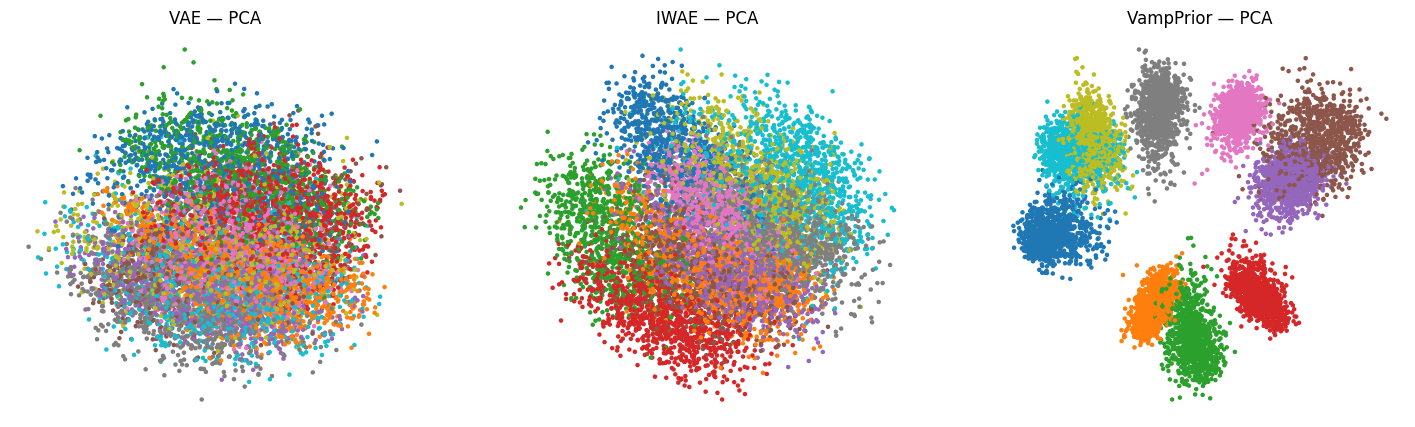

In [77]:
plt.figure(figsize=(18,5))

for i, (name, (mu, logvar, z, labels)) in enumerate(latents.items()):
    from sklearn.decomposition import PCA
    z2 = PCA(n_components=2).fit_transform(z.numpy())

    plt.subplot(1,3,i+1)
    plt.scatter(z2[:,0], z2[:,1], c=labels.numpy(), s=5, cmap="tab10")
    plt.title(f"{name} — PCA")
    plt.axis("off")

plt.show()


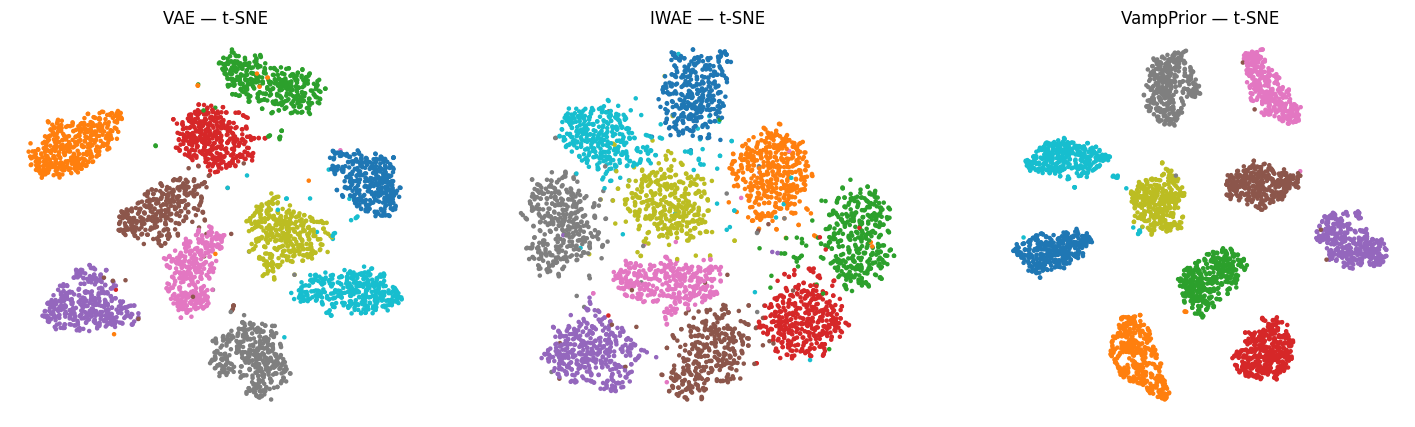

In [78]:
plt.figure(figsize=(18,5))

from sklearn.manifold import TSNE

for i, (name, (mu, logvar, z, labels)) in enumerate(latents.items()):
    z2 = TSNE(n_components=2, perplexity=30).fit_transform(z[:4000].numpy())

    plt.subplot(1,3,i+1)
    plt.scatter(z2[:,0], z2[:,1], c=labels[:4000].numpy(), s=5, cmap="tab10")
    plt.title(f"{name} — t-SNE")
    plt.axis("off")

plt.show()


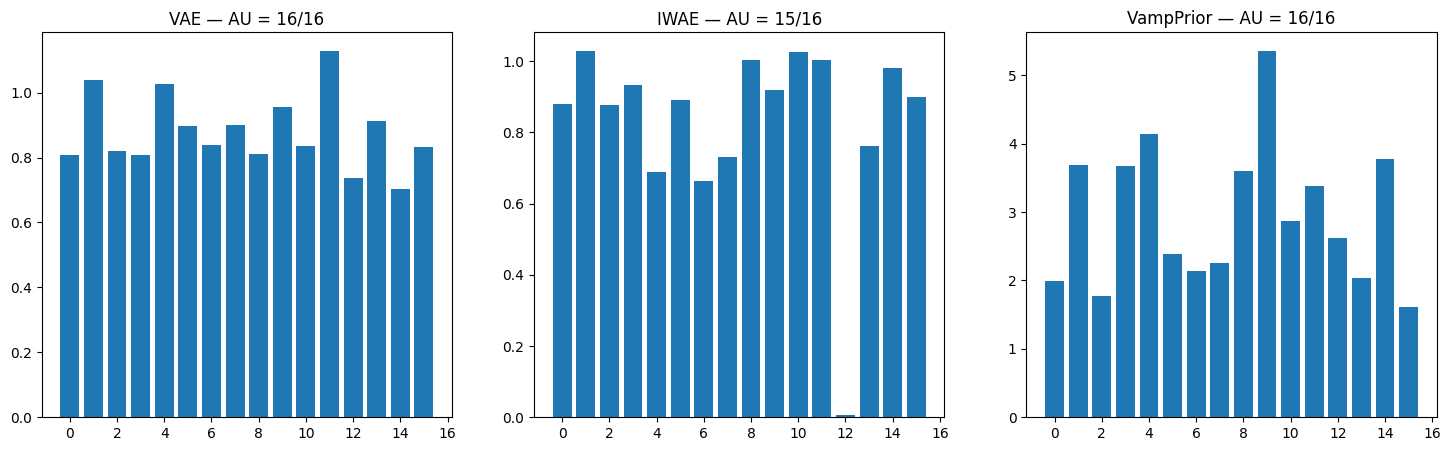

In [79]:
plt.figure(figsize=(18,5))

for i, (name, (mu, logvar, z, labels)) in enumerate(latents.items()):
    var, active = compute_active_units(mu)
    plt.subplot(1,3,i+1)
    plt.bar(range(len(var)), var)
    plt.title(f"{name} — AU = {active}/{len(var)}")

plt.show()


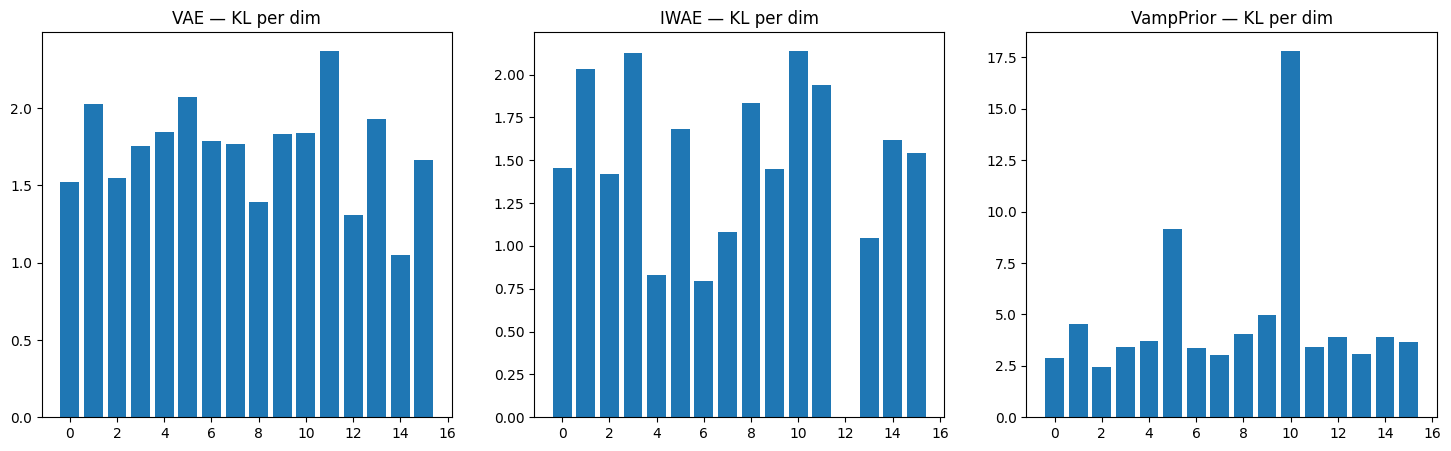

In [101]:
plt.figure(figsize=(18,5))

for i, (name, (mu, logvar, z, labels)) in enumerate(latents.items()):
    kl = kl_per_dimension(mu, logvar).mean(dim=0).numpy()
    plt.subplot(1,3,i+1)
    plt.bar(range(len(kl)), kl)
    plt.title(f"{name} — KL per dim")

plt.show()


In [81]:
for name, (mu, logvar, z, labels) in latents.items():
    acc = linear_probe(z.numpy(), labels.numpy())
    print(f"{name:10s} linear probe accuracy: {acc:.3f}")


VAE        linear probe accuracy: 0.992
IWAE       linear probe accuracy: 0.989
VampPrior  linear probe accuracy: 1.000


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-66.78117..3.7526433].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-67.46842..3.5537837].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-67.24989..3.2425997].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-67.67297..3.3271697].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-68.87893..3.4453466].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-69.15996..3.9089468].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-69.39627..3.69

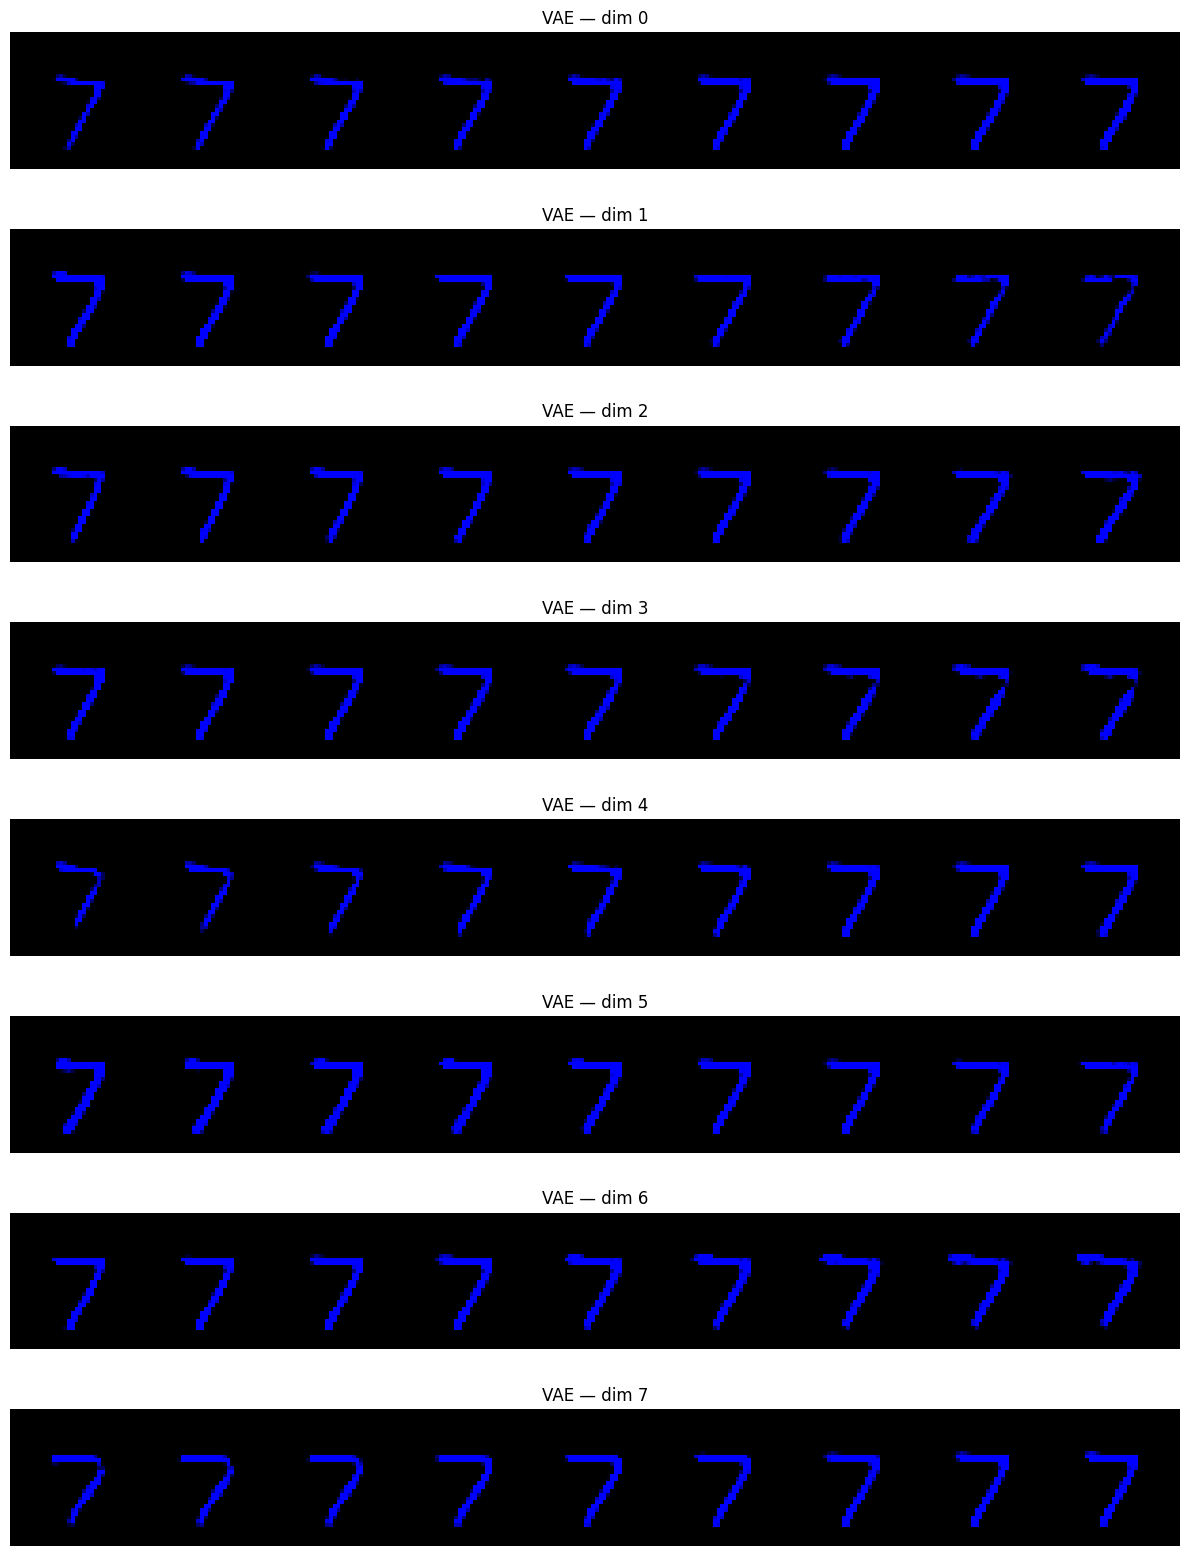

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-92.24435..4.12857].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-94.26112..4.324272].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-92.24958..4.953421].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-73.152725..3.0931578].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-94.148224..3.9739].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-96.85887..4.3788404].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-93.57182..4.1399193

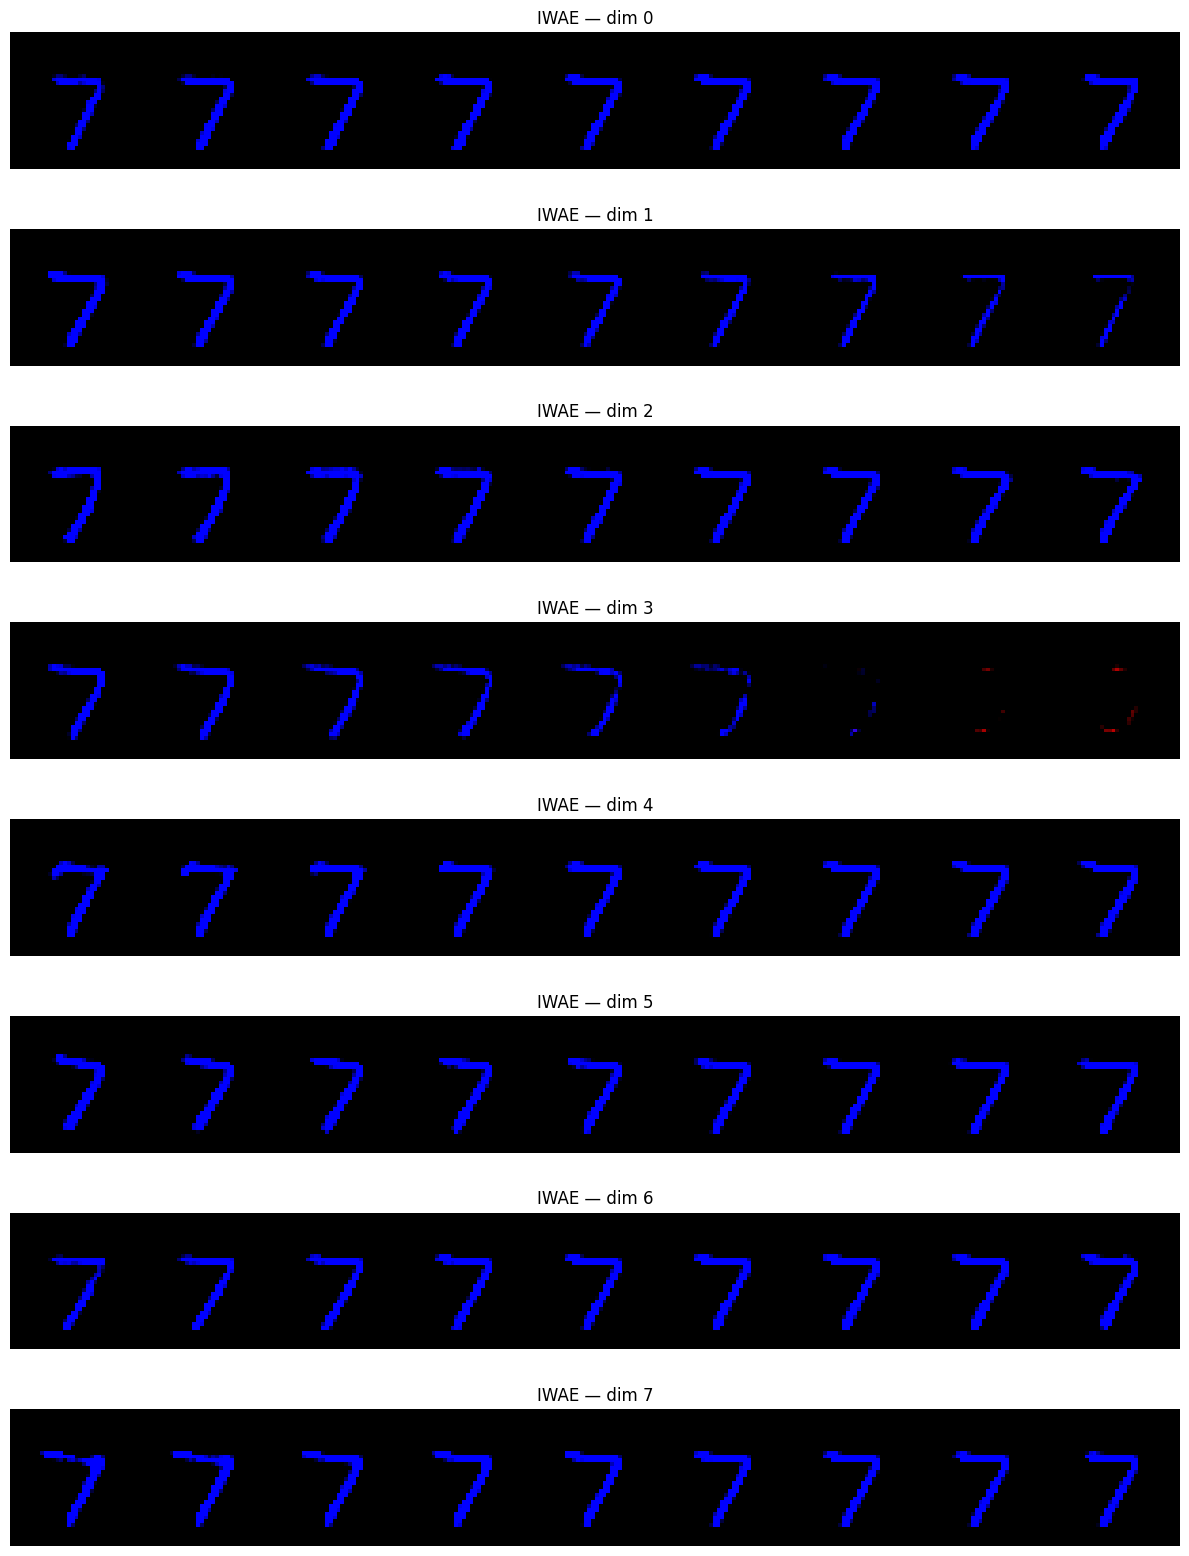

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-89.798836..3.6937714].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-80.01248..3.5084915].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-88.822014..3.3528082].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-99.089195..3.453356].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-89.105034..3.4369311].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-102.58921..2.7513418].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-96.48826..

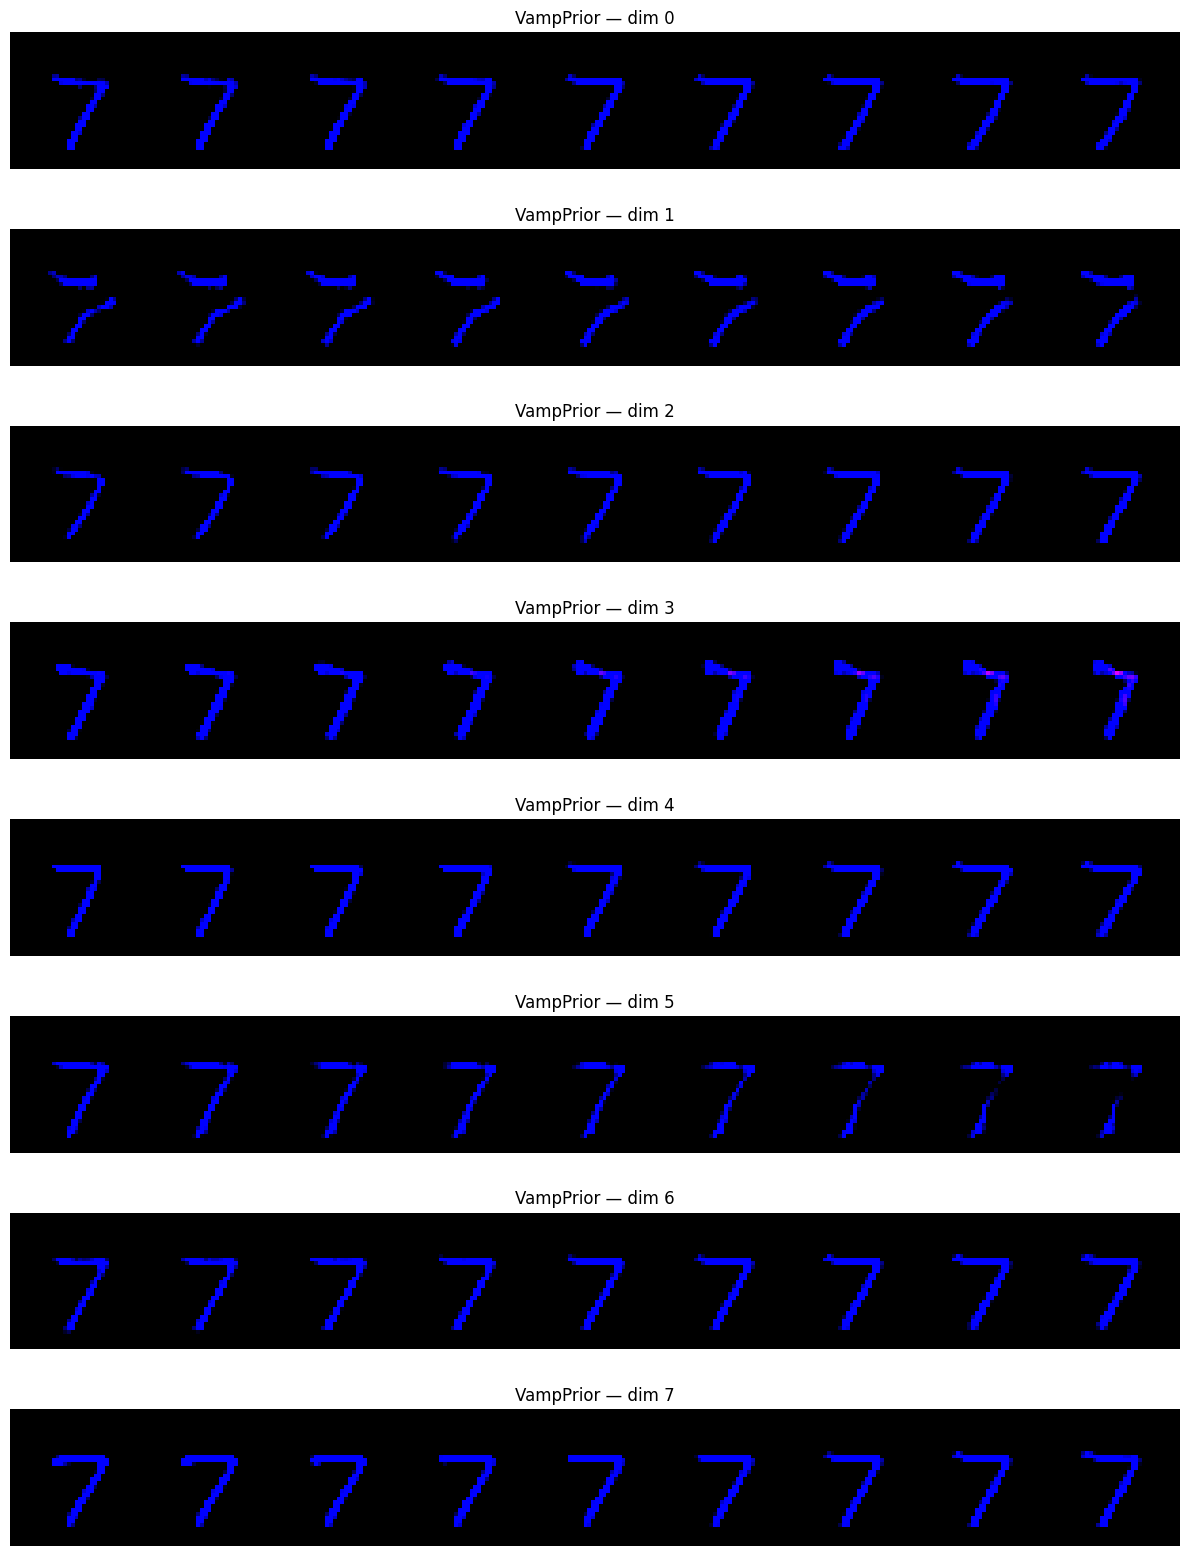

In [ ]:

def show_traversal(model, name, x0, dims=8):
    """
    Renders latent traversal for first `dims` dimensions.
    """
    fig, axes = plt.subplots(dims, 1, figsize=(12, 2*dims))

    for d in range(dims):
        imgs = latent_traversal(model, x0, dim=d, steps=9, sigma_scale=5, device=device)
        grid = make_grid(imgs, nrow=9)

        axes[d].imshow(grid.permute(1,2,0))
        axes[d].axis("off")
        axes[d].set_title(f"{name} — dim {d}")

    plt.tight_layout()
    plt.show()


# pick 1 sample
x0, _ = next(iter(val_dl))
x0 = x0[:1].to(device)


# run traversal for all models
for name, model in MODELS.items():
    show_traversal(model, name, x0, dims=8)

